Dirty Dataset Shape: (192635, 14)

=== EDA: Data Overview ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192635 entries, 0 to 192634
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             191671 non-null  datetime64[ns]
 1   sku              192635 non-null  object        
 2   brand            192635 non-null  object        
 3   segment          192635 non-null  object        
 4   category         192635 non-null  object        
 5   channel          192635 non-null  object        
 6   region           192635 non-null  object        
 7   pack_type        192635 non-null  object        
 8   price_unit       183106 non-null  float64       
 9   promotion_flag   192635 non-null  int64         
 10  delivery_days    192635 non-null  int64         
 11  stock_available  183309 non-null  float64       
 12  delivered_qty    183106 non-null  float64       
 13  units_sold  

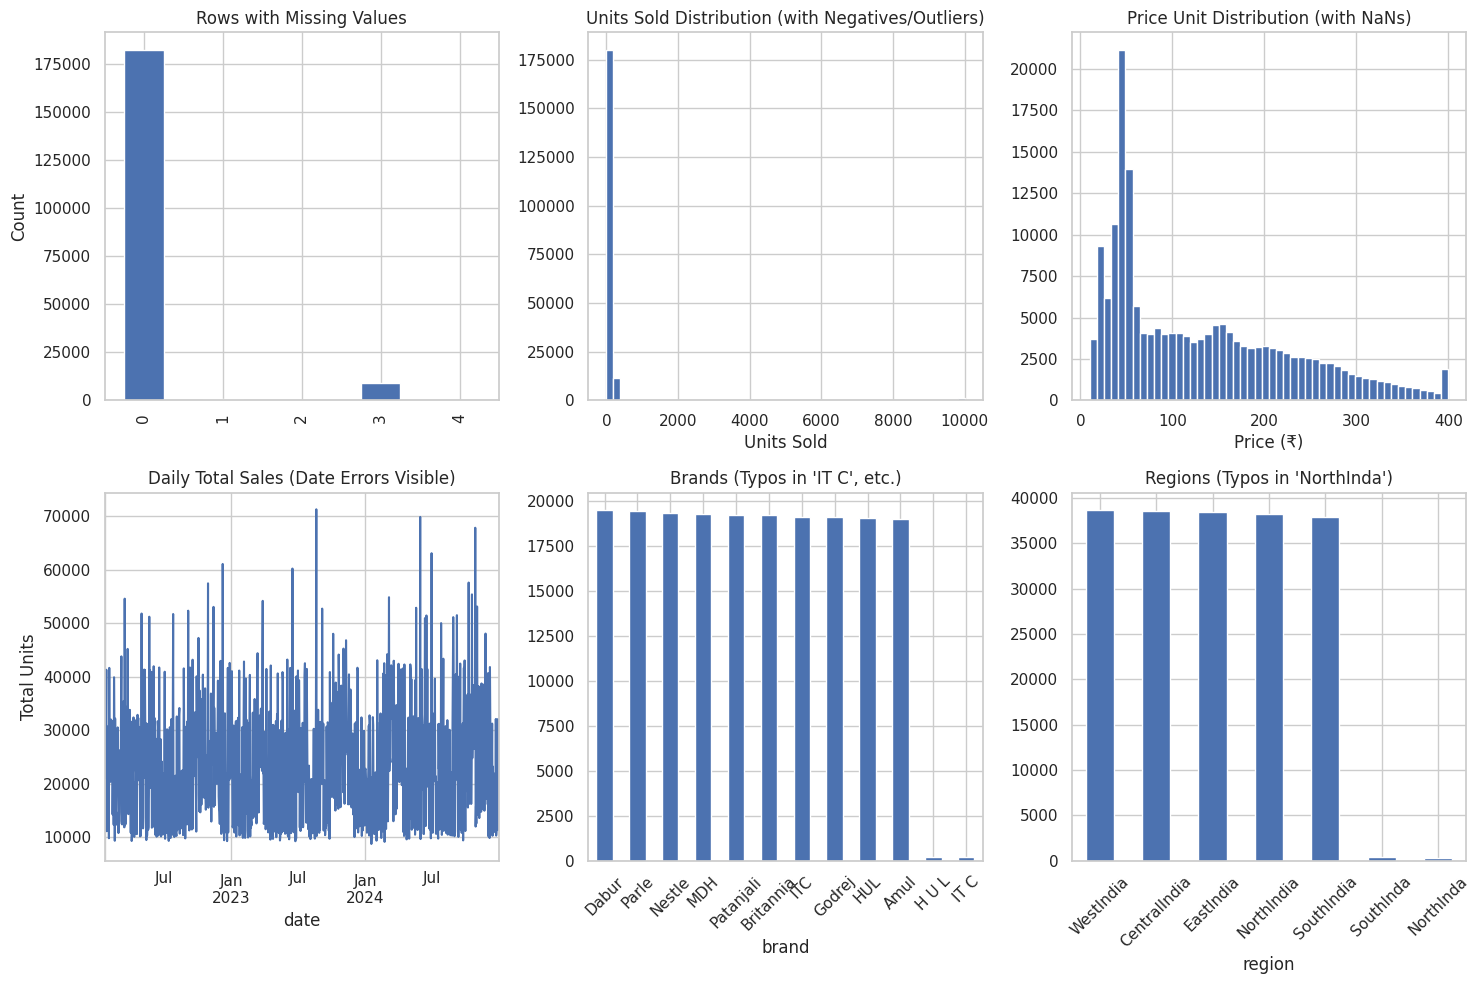


EDA Summary: Dataset has  errors. Proceed to cleaning.


In [7]:
# === Step 2: EDA on Dirty Dataset ===
# Load the dirty dataset and perform exploratory analysis to identify issues
# (missing values, negatives, duplicates, invalid dates, categorical errors)

df_dirty = pd.read_csv('indian_fmcg_dirty_dataset.csv', parse_dates=['date'])  # Remove errors='coerce' from read_csv
df_dirty['date'] = pd.to_datetime(df_dirty['date'], errors='coerce') # Apply to_datetime with errors='coerce' after reading
print("Dirty Dataset Shape:", df_dirty.shape)
print("\n=== EDA: Data Overview ===")
print(df_dirty.info())  # Types and non-null counts (shows NaNs in date/numerics)

print("\n=== Missing Values Summary ===")
missing_summary = df_dirty.isnull().sum()
print(missing_summary[missing_summary > 0])  # Only show columns with NaNs (~5% in stock_available, price_unit, etc.)

print("\n=== Negative/Outlier Check ===")
print("Negative values in key numerics:")
for col in ['units_sold', 'stock_available', 'delivered_qty', 'delivery_days']:
    # Ensure the column is numeric before checking for negatives
    if pd.api.types.is_numeric_dtype(df_dirty[col]):
        neg_count = (df_dirty[col] < 0).sum()
        print(f"{col}: {neg_count} negatives ({neg_count/len(df_dirty)*100:.1f}%)")
    else:
        print(f"{col}: Not a numeric column, skipping negative check.")


# Outliers: Z-score >3 or beyond 1.5*IQR
print("\nOutliers (beyond 1.5*IQR):")
for col in ['units_sold', 'price_unit', 'stock_available']:
     if pd.api.types.is_numeric_dtype(df_dirty[col]):
        Q1 = df_dirty[col].quantile(0.25)
        Q3 = df_dirty[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_count = ((df_dirty[col] < (Q1 - 1.5 * IQR)) | (df_dirty[col] > (Q3 + 1.5 * IQR))).sum()
        print(f"{col}: {outlier_count} outliers ({outlier_count/len(df_dirty)*100:.1f}%)")
     else:
        print(f"{col}: Not a numeric column, skipping outlier check.")


print("\n=== Duplicates ===")
dup_count = df_dirty.duplicated().sum()
print(f"Duplicate rows: {dup_count} ({dup_count/len(df_dirty)*100:.1f}%)")

print("\n=== Invalid Dates ===")
invalid_date_count = df_dirty['date'].isna().sum()
print(f"Invalid/NaT dates: {invalid_date_count} ({invalid_date_count/len(df_dirty)*100:.1f}%)")

print("\n=== Categorical Errors (Typos/Outliers) ===")
print("Unique brands (check for typos like 'IT C'):")
print(df_dirty['brand'].value_counts().head(10))  # Shows anomalies
print("\nUnique regions:")
print(df_dirty['region'].value_counts())  # Shows 'NorthInda' etc.

# Visual EDA
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
# Ensure the data for the bar plot is numeric before plotting
missing_values_counts = df_dirty.isnull().sum(axis=1).value_counts().sort_index()
if not missing_values_counts.empty:
    ax1 = missing_values_counts.plot(kind='bar')
    ax1.set_title("Rows with Missing Values")
    ax1.set_ylabel("Count")
else:
    plt.text(0.5, 0.5, "No missing values to plot", horizontalalignment='center', verticalalignment='center')


plt.subplot(2, 3, 2)
# Ensure the column is numeric before plotting
if pd.api.types.is_numeric_dtype(df_dirty['units_sold']):
    ax2 = df_dirty['units_sold'].hist(bins=50)
    ax2.set_title("Units Sold Distribution (with Negatives/Outliers)")
    ax2.set_xlabel("Units Sold")
else:
    plt.text(0.5, 0.5, "Units Sold is not numeric", horizontalalignment='center', verticalalignment='center')


plt.subplot(2, 3, 3)
# Ensure the column is numeric before plotting
if pd.api.types.is_numeric_dtype(df_dirty['price_unit']):
    ax3 = df_dirty['price_unit'].hist(bins=50)
    ax3.set_title("Price Unit Distribution (with NaNs)")
    ax3.set_xlabel("Price (₹)")
else:
     plt.text(0.5, 0.5, "Price Unit is not numeric", horizontalalignment='center', verticalalignment='center')


plt.subplot(2, 3, 4)
# Ensure the date column is datetime and units_sold is numeric before plotting
if pd.api.types.is_datetime64_any_dtype(df_dirty['date']) and pd.api.types.is_numeric_dtype(df_dirty['units_sold']):
    ax4 = df_dirty.groupby('date')['units_sold'].sum().plot()
    ax4.set_title("Daily Total Sales (Date Errors Visible)")
    ax4.set_ylabel("Total Units")
else:
    plt.text(0.5, 0.5, "Date or Units Sold column not in correct format for plotting", horizontalalignment='center', verticalalignment='center')


plt.subplot(2, 3, 5)
ax5 = df_dirty['brand'].value_counts().plot(kind='bar')
ax5.set_title("Brands (Typos in 'IT C', etc.)")
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
ax6 = df_dirty['region'].value_counts().plot(kind='bar')
ax6.set_title("Regions (Typos in 'NorthInda')")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nEDA Summary: Dataset has  errors. Proceed to cleaning.")

=== Preprocessing Steps ===

1. Imputing Missing Values...
price_unit: Filled 9529 NaNs with median 104.34199917357964
stock_available: Filled 9326 NaNs with median 275.0
delivered_qty: Filled 9529 NaNs with median 250.0
delivery_days: Filled 0 NaNs with median 3.0
units_sold: Filled 0 NaNs with median 53.0
Date: Filled 964 NaTs with default date
brand: Filled NaNs with mode 'Dabur'
segment: Filled NaNs with mode 'Cleaning-Seg1'
channel: Filled NaNs with mode 'Kirana'
region: Filled NaNs with mode 'WestIndia'
pack_type: Filled NaNs with mode 'Tin'

2. Clipping Negatives and Outliers...
units_sold: Clipped 2579 negatives to 0
units_sold: Capped 1925 outliers at 313.0
stock_available: Clipped 1900 negatives to 0
stock_available: Capped 1906 outliers at 499.0
delivered_qty: Clipped 0 negatives to 0
delivered_qty: Capped 1797 outliers at 396.0
delivery_days: Clipped 0 negatives to 0
delivery_days: Capped 0 outliers at 5.0
price_unit: Capped outliers at 391.73372629994043

3. Removing Dupli

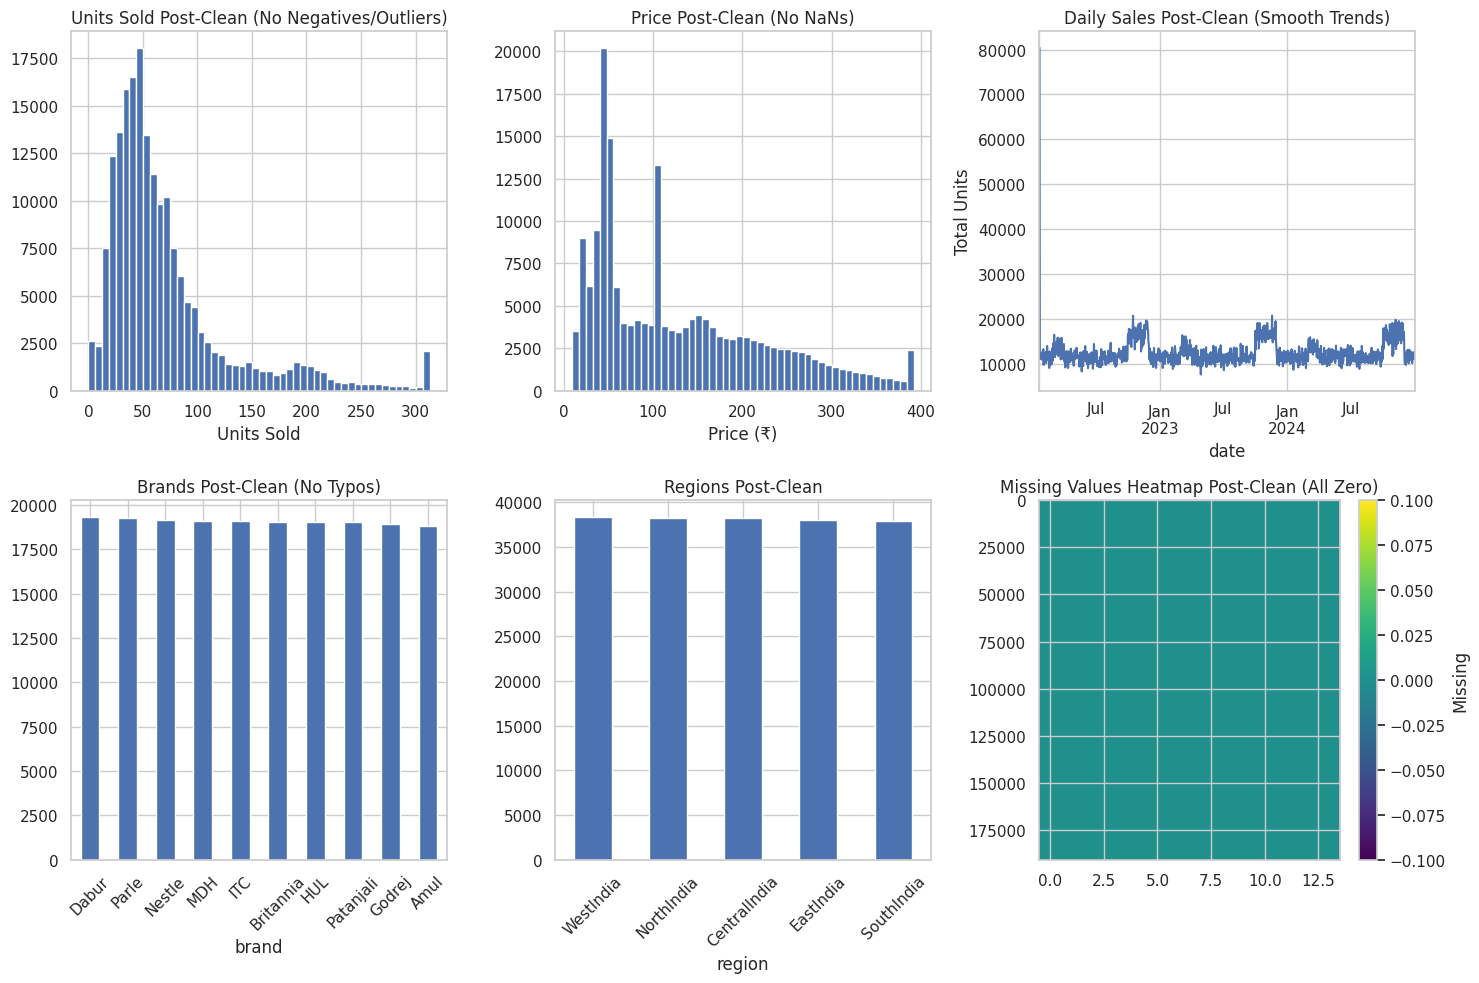

Preprocessing Complete! Dataset is now clean for feature engineering and modeling.


In [9]:
# === Step 3: Preprocessing - Solving the Errors ===
# Clean the dirty dataset: Impute NaNs, clip negatives/outliers, dedup, fix dates, standardize categoricals
# This "solves" the issues identified in EDA for clean ML input

df_clean = df_dirty.copy()

print("=== Preprocessing Steps ===")

# 1. Handle Missing Values (Impute with medians for numerics; mode for categoricals)
print("\n1. Imputing Missing Values...")
numeric_cols = ['price_unit', 'stock_available', 'delivered_qty', 'delivery_days', 'units_sold']
for col in numeric_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"{col}: Filled {df_dirty[col].isnull().sum()} NaNs with median {median_val}")

# For date (already NaT from coerce)
df_clean['date'].fillna(pd.Timestamp('2022-01-21'), inplace=True)  # Forward fill or default
print(f"Date: Filled {invalid_date_count} NaTs with default date")

# Categorical (forward fill or mode)
cat_cols = ['brand', 'segment', 'channel', 'region', 'pack_type']
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"{col}: Filled NaNs with mode '{mode_val}'")

# 2. Clip Negatives and Outliers
print("\n2. Clipping Negatives and Outliers...")
for col in ['units_sold', 'stock_available', 'delivered_qty', 'delivery_days']:
    # Negatives to 0
    neg_mask = df_clean[col] < 0
    df_clean.loc[neg_mask, col] = 0
    print(f"{col}: Clipped {neg_mask.sum()} negatives to 0")

    # Outliers: Cap at 99th percentile
    upper_limit = df_clean[col].quantile(0.99)
    outlier_mask = df_clean[col] > upper_limit
    df_clean.loc[outlier_mask, col] = upper_limit
    print(f"{col}: Capped {outlier_mask.sum()} outliers at {upper_limit}")

# Price outliers: Similar cap
price_upper = df_clean['price_unit'].quantile(0.99)
df_clean.loc[df_clean['price_unit'] > price_upper, 'price_unit'] = price_upper
print(f"price_unit: Capped outliers at {price_upper}")

# 3. Remove Duplicates
print("\n3. Removing Duplicates...")
initial_rows = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df_clean)} duplicates ({(initial_rows - len(df_clean))/initial_rows*100:.1f}%)")

# 4. Fix Invalid Dates
print("\n4. Fixing Dates...")
# Already coerced to NaT and filled; re-sort
df_clean = df_clean.sort_values(['sku', 'date']).reset_index(drop=True)
print("Dates sorted; invalid ones filled with default.")

# 5. Standardize Categorical Typos (Simple string cleaning/mapping)
print("\n5. Cleaning Categorical Typos...")
# Brand fixes
brand_mapping = {'IT C': 'ITC', 'H U L': 'HUL', 'Nsetle': 'Nestle'}  # Add more as needed
df_clean['brand'] = df_clean['brand'].replace(brand_mapping)

# Region fixes
region_mapping = {'NorthInda': 'NorthIndia', 'SouthInda': 'SouthIndia', 'EastInda': 'EastIndia'}
df_clean['region'] = df_clean['region'].replace(region_mapping)

# Verify
print("Post-clean brands (top 5):")
print(df_clean['brand'].value_counts().head())
print("Post-clean regions:")
print(df_clean['region'].value_counts())

# Final Validation
print("\n=== Post-Preprocessing Validation ===")
print("Shape:", df_clean.shape)
print("Missing Values:", df_clean.isnull().sum().sum())
print("Negatives in units_sold:", (df_clean['units_sold'] < 0).sum())
print("Duplicates:", df_clean.duplicated().sum())
print("Invalid Dates:", df_clean['date'].isna().sum())

# Save Clean Dataset
df_clean.to_csv('indian_fmcg_clean_dataset.csv', index=False)
print("\nClean dataset saved as 'indian_fmcg_clean_dataset.csv'. Ready for ML!")

# Quick Post-Clean Viz
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
ax1 = df_clean['units_sold'].hist(bins=50)
ax1.set_title("Units Sold Post-Clean (No Negatives/Outliers)")
ax1.set_xlabel("Units Sold")

plt.subplot(2, 3, 2)
ax2 = df_clean['price_unit'].hist(bins=50)
ax2.set_title("Price Post-Clean (No NaNs)")
ax2.set_xlabel("Price (₹)")

plt.subplot(2, 3, 3)
ax3 = df_clean.groupby('date')['units_sold'].sum().plot()
ax3.set_title("Daily Sales Post-Clean (Smooth Trends)")
ax3.set_ylabel("Total Units")

plt.subplot(2, 3, 4)
ax4 = df_clean['brand'].value_counts().plot(kind='bar')
ax4.set_title("Brands Post-Clean (No Typos)")
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
ax5 = df_clean['region'].value_counts().plot(kind='bar')
ax5.set_title("Regions Post-Clean")
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
ax6 = plt.imshow(df_clean.isnull(), aspect='auto', cmap='viridis')
plt.title("Missing Values Heatmap Post-Clean (All Zero)")
plt.colorbar(label="Missing")

plt.tight_layout()
plt.show()

print("Preprocessing Complete! Dataset is now clean for feature engineering and modeling.")